In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('D:/Semantic-Ecommerce-Recommender/data/processed/amazon_cleaned.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape: (8000, 14)
Columns: ['asin', 'title', 'imgUrl', 'productURL', 'stars', 'reviews', 'price', 'listPrice', 'category_id', 'isBestSeller', 'boughtInLastMonth', 'category_name', 'price_capped', 'reviews_capped']


,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth,category_name,price_capped,reviews_capped
0,B0C72BBX2K,340-Piece Drywall Anchors and Screws Combo Pac...,https://m.media-amazon.com/images/I/719Vn02sGs...,https://www.amazon.com/dp/B0C72BBX2K,4.6,0,6.90,0.00,154,False,700,Fasteners,6.90,0.0
1,B0BKGCPHVH,"Girl Tutu Skirts,3Layers Tulle Sequin Star Bal...",https://m.media-amazon.com/images/I/51lttzoeKl...,https://www.amazon.com/dp/B0BKGCPHVH,4.3,44,7.99,0.00,91,False,0,Girls' Clothing,7.99,44.0
2,B08M4BN431,Corsair iCUE 5000X RGB Tempered Glass Mid-Towe...,https://m.media-amazon.com/images/I/716nFovNhS...,https://www.amazon.com/dp/B08M4BN431,4.8,0,189.99,214.99,63,False,0,Computer Components,189.99,0.0


In [ ]:
# Feature 1: discount_percentage
df['discount_pct'] = np.where(
    df['listPrice'] > 0,
    ((df['listPrice'] - df['price']) / df['listPrice'] * 100).round(2),
    0
)

In [3]:
# Feature 2: popularity_score 
df['popularity_score'] = (
    0.6 * df['reviews'] + 0.4 * df['boughtInLastMonth']
).round(2)

In [4]:
# Feature 3: value_score 
df['value_score'] = (df['stars'] / (df['price'] + 1)).round(4)

In [5]:
# Feature 4: title_length 
df['title_length'] = df['title'].str.split().str.len()

In [ ]:
# Feature 5: combined_text
df['combined_text'] = df['title'] + ' ' + df['category_name']

In [7]:
print("New features created:")
print(df[['title', 'discount_pct', 'popularity_score', 'value_score', 'title_length', 'combined_text']].head())
print(f"\nShape after feature engineering: {df.shape}")

New features created:
                                               title  discount_pct  \
0  340-Piece Drywall Anchors and Screws Combo Pac...          0.00   
1  Girl Tutu Skirts,3Layers Tulle Sequin Star Bal...          0.00   
2  Corsair iCUE 5000X RGB Tempered Glass Mid-Towe...         11.63   
3  Dr. Scholl's Moleskin Padding Strips, 3 Strips...         10.06   
4  COKOHAPPY Halloween Temporary Face Tattoos Mak...          0.00   

   popularity_score  value_score  title_length  \
0             280.0       0.5823            23   
1              26.4       0.4783            18   
2               0.0       0.0251            13   
3            1200.0       0.6724            32   
4             447.8       0.5382            29   

                                       combined_text  
0  340-Piece Drywall Anchors and Screws Combo Pac...  
1  Girl Tutu Skirts,3Layers Tulle Sequin Star Bal...  
2  Corsair iCUE 5000X RGB Tempered Glass Mid-Towe...  
3  Dr. Scholl's Moleskin Padding Str

In [8]:
# Encode category_name as numeric label
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['category_name'])

print(f"Unique categories encoded: {df['category_encoded'].nunique()}")
print(f"\nSample encoding:")
print(df[['category_name', 'category_encoded']].drop_duplicates().head(10))

Unique categories encoded: 248

Sample encoding:
                    category_name  category_encoded
0                       Fasteners                65
1                 Girls' Clothing                78
2             Computer Components                48
3            Health Care Products                87
4                          Makeup               132
6                       Computers                53
7               Boys' Accessories                33
8              Laptop Accessories               122
9   Kids' Dress Up & Pretend Play               107
10                   Cat Supplies                44


In [9]:
scaler = MinMaxScaler()

cols_to_scale = ['stars', 'price', 'reviews', 'boughtInLastMonth',
                 'discount_pct', 'popularity_score', 'value_score']

df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Scaled features (0-1 range):")
print(df_scaled[cols_to_scale].describe().round(3))

Scaled features (0-1 range):
          stars     price   reviews  boughtInLastMonth  discount_pct  \
count  8000.000  8000.000  8000.000           8000.000      8000.000   
mean      0.849     0.014     0.004              0.007         0.075   
std       0.117     0.031     0.026              0.031         0.146   
min       0.000     0.000     0.000              0.000         0.000   
25%       0.800     0.004     0.000              0.000         0.006   
50%       0.875     0.007     0.000              0.000         0.006   
75%       0.925     0.012     0.000              0.005         0.072   
max       1.000     1.000     1.000              1.000         1.000   

       popularity_score  value_score  
count          8000.000     8000.000  
mean              0.006        0.107  
std               0.028        0.078  
min               0.000        0.000  
25%               0.000        0.052  
50%               0.000        0.094  
75%               0.003        0.146  
max       

In [11]:
X = df_scaled[cols_to_scale]
y = df_scaled['category_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (6400, 7)
Test set: (1600, 7)


In [12]:
# Build TF-IDF matrix on combined_text
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df['combined_text'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (8000, 5000)


In [17]:
def recommend_tfidf(query, top_n=5):
    query_vec = tfidf.transform([query])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = similarities.argsort()[::-1][:top_n]
    
    results = df.iloc[top_indices][['title', 'category_name', 'stars', 'price']].copy()
    results['similarity_score'] = similarities[top_indices].round(4)
    return results

# Test queries
print("Query: laptop for video editing")
print(recommend_tfidf("laptop for video editing", top_n=5))

print("\nQuery: wireless headphones noise cancelling")
print(recommend_tfidf("wireless headphones noise cancelling", top_n=5))

print("\n Query: yoga mat non slip")
print(recommend_tfidf("yoga mat non slip", top_n=5))

Query: laptop for video editing
                                                  title       category_name  \
2955  Marvel Deadpool Unicorns And Rainbows Laptop B...         Laptop Bags   
2890  KROSER Laptop Bag Laptop Briefcase Water-Repel...  Laptop Accessories   
1671                 TaliCor All About You Thumball, 4"         Video Games   
1851  EVERKI EKS620 Urbanite Laptop Vertical Messeng...         Laptop Bags   
716   Fast Charger Fit for Lenovo Thinkpad T480 T480...  Laptop Accessories   

      stars   price  similarity_score  
2955    4.5   39.95            0.4205  
2890    4.7   34.99            0.4181  
1671    4.5   18.99            0.3644  
1851    4.0  109.09            0.3622  
716     4.5   15.99            0.3533  

Query: wireless headphones noise cancelling
                                                  title         category_name  \
1880  Gsoemon Active Noise Cancelling Wireless Earbu...  Headphones & Earbuds   
7525  Active Noise Cancelling Headphones E600P

In [19]:
# Evaluation: for test queries, checking if top results match expected category
def evaluate_category_hit_rate(sample_size=100):
    test_sample = df.sample(sample_size, random_state=42)
    hits = 0
    
    for _, row in test_sample.iterrows():
        results = recommend_tfidf(row['title'], top_n=5)
        if row['category_name'] in results['category_name'].values:
            hits += 1
    
    hit_rate = hits / sample_size * 100
    return hit_rate

hit_rate = evaluate_category_hit_rate(100)
print(f"Baseline TF-IDF Category Hit Rate: {hit_rate:.1f}%")
print(f"({hit_rate:.1f}% of time correct category appears in top-5 results)")

Baseline TF-IDF Category Hit Rate: 99.0%
(99.0% of time correct category appears in top-5 results)


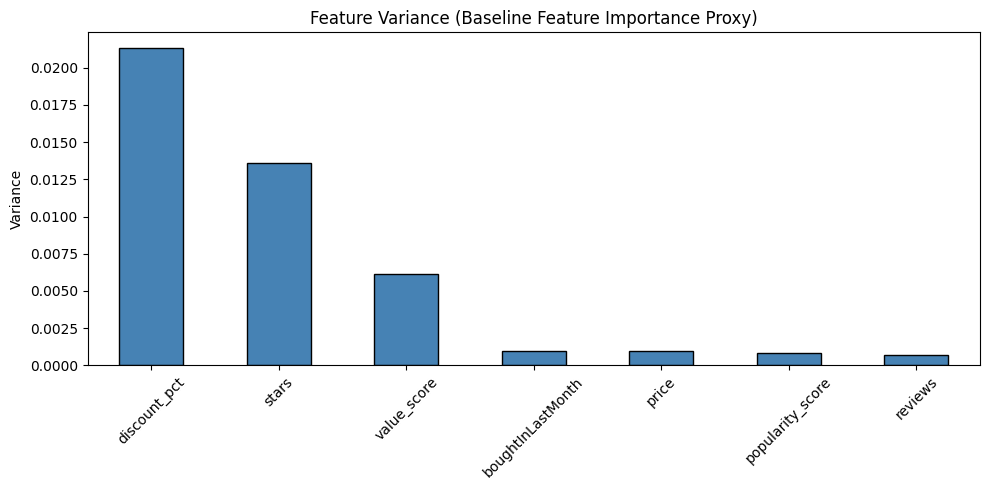

In [15]:
# Show feature variance as proxy for importance in the baseline
feature_variance = df_scaled[cols_to_scale].var().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feature_variance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Variance (Baseline Feature Importance Proxy)')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/feature_importance_baseline.png')
plt.show()

In [16]:
import os
os.makedirs('D:/Semantic-Ecommerce-Recommender/models', exist_ok=True)

# Save TF-IDF model
joblib.dump(tfidf, 'D:/Semantic-Ecommerce-Recommender/models/tfidf_baseline.pkl')

# Save scaler
joblib.dump(scaler, 'D:/Semantic-Ecommerce-Recommender/models/scaler.pkl')

# Save label encoder
joblib.dump(le, 'D:/Semantic-Ecommerce-Recommender/models/label_encoder.pkl')

# Save engineered dataset
df.to_csv('D:/Semantic-Ecommerce-Recommender/data/processed/amazon_featured.csv', index=False)

print("Saved:")
print("  models/tfidf_baseline.pkl")
print("  models/scaler.pkl")
print("  models/label_encoder.pkl")
print("  data/processed/amazon_featured.csv")

Saved:
  models/tfidf_baseline.pkl
  models/scaler.pkl
  models/label_encoder.pkl
  data/processed/amazon_featured.csv
